In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np


def plot_waveforms(file, save_dir=None, show=True):
    fig, ax = plt.subplots(3, 1, figsize=(10, 8))

    time = np.loadtxt(file, skiprows=17, usecols=0, delimiter=',', dtype=float)
    ch1_voltages = np.loadtxt(file, skiprows=17, usecols=1, delimiter=',', dtype=float)
    ch2_voltages = np.loadtxt(file, skiprows=17, usecols=2, delimiter=',', dtype=float)

    ax[0].plot(time, ch1_voltages, label='ch1', color='yellow')
    ax[1].plot(time, ch2_voltages, label='ch2', color='violet')

    ax[2].plot(time, ch1_voltages, label="ch1", color="yellow")
    ax[2].plot(time, ch2_voltages, label="ch2", color="violet")

    for axis in ax:
        axis.set_facecolor("black")
        axis.grid()
        axis.legend()
        axis.set_ylabel("Voltage (V)")

    ax[2].set_xlabel("Time (s)")

    fig.tight_layout()

    if save_dir is not None:
        save_dir = Path(save_dir)
        save_dir.mkdir(parents=True, exist_ok=True)
        out_path = save_dir / f"{Path(file).stem}.png"
        fig.savefig(out_path, dpi=150)

    if show:
        plt.show()
    else:
        plt.close(fig)


def plot_directory(data_dir, save_dir=None, show=False):
    """
    Apply plot_waveforms() to every CSV file in data_dir.

    Parameters
    ----------
    data_dir : str or Path
        Directory containing the CSV waveform files.
    save_dir : str or Path, optional
        If given, each plot is saved as a PNG here (named after the source CSV).
    show : bool
        If True, blocks and displays each plot interactively (not recommended
        for large batches). Default False.
    """
    data_dir = Path(data_dir)
    if not data_dir.is_dir():
        raise NotADirectoryError(f"Directory not found: {data_dir}")

    csv_files = sorted(
        path for path in data_dir.iterdir()
        if path.is_file() and path.suffix.lower() == ".csv"
    )

    processed = 0
    skipped = []

    for csv_path in csv_files:
        try:
            plot_waveforms(csv_path, save_dir=save_dir, show=show)
            processed += 1
        except Exception as error:
            skipped.append((csv_path.name, str(error)))
            print(f"Skipping {csv_path.name}: {error}")

    print(f"Processed: {processed} files")
    print(f"Skipped:   {len(skipped)} files")
    if save_dir is not None:
        print(f"Plots saved to: {Path(save_dir).resolve()}")

    return processed, skipped

Skipping ._SaveOnEvent_ALL_20260904001131655.csv: 'utf-8' codec can't decode byte 0xb0 in position 37: invalid start byte
Skipping ._SaveOnEvent_ALL_20260904041907300.csv: 'utf-8' codec can't decode byte 0xb0 in position 37: invalid start byte


/tmp/ipykernel_553773/4293750225.py:9: UserWarning: loadtxt: input contained no data: "/archive/4sepmdetectshigherupwkndrun/SaveOnEvent_ALL_20260904000836776.csv"
  time = np.loadtxt(file, skiprows=17, usecols=0, delimiter=',', dtype=float)
/tmp/ipykernel_553773/4293750225.py:10: UserWarning: loadtxt: input contained no data: "/archive/4sepmdetectshigherupwkndrun/SaveOnEvent_ALL_20260904000836776.csv"
  ch1_voltages = np.loadtxt(file, skiprows=17, usecols=1, delimiter=',', dtype=float)
/tmp/ipykernel_553773/4293750225.py:11: UserWarning: loadtxt: input contained no data: "/archive/4sepmdetectshigherupwkndrun/SaveOnEvent_ALL_20260904000836776.csv"
  ch2_voltages = np.loadtxt(file, skiprows=17, usecols=2, delimiter=',', dtype=float)


Processed: 663 files
Skipped:   2 files
Plots saved to: /home/sandhya/Desktop/muon-analysis/4sep_weekend_plots


(663,
 [('._SaveOnEvent_ALL_20260904001131655.csv',
   "'utf-8' codec can't decode byte 0xb0 in position 37: invalid start byte"),
  ('._SaveOnEvent_ALL_20260904041907300.csv',
   "'utf-8' codec can't decode byte 0xb0 in position 37: invalid start byte")])

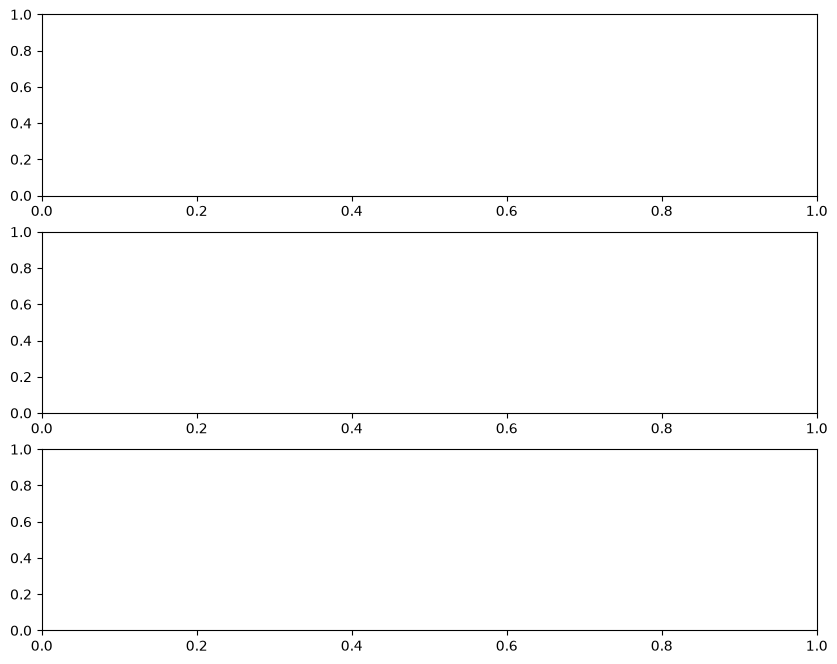

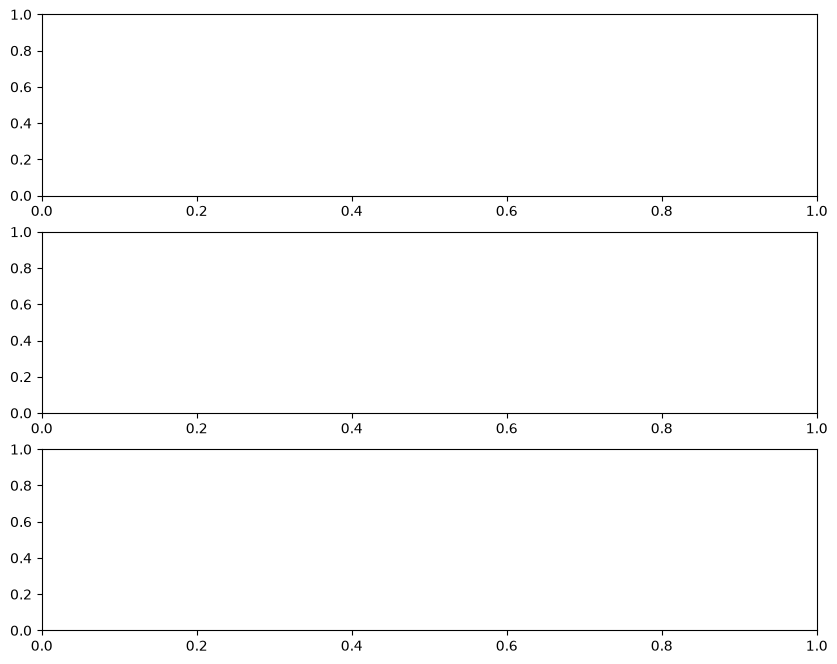

In [2]:
data_dir = "/archive/4sepmdetectshigherupwkndrun/"
plot_directory(data_dir, save_dir="4sep_weekend_plots/") 